# Comparative CFD Study of Obstacle Shapes in Channel Flow

A 2-D incompressible Navier-Stokes simulation comparing how six obstacle geometries — **triangle, square, pentagon, hexagon, dodecagon, and circle** — affect flow resistance and wake recovery in a confined rectangular channel. All shapes share the same circumradius ($R = 0.25$ m) and are trimmed at $x = 2.0$ m, ensuring geometrically fair comparisons.

## Governing Equations

**Continuity** (incompressibility):
$$\nabla \cdot \mathbf{u} = 0$$

**Momentum** (Navier-Stokes):
$$\rho \frac{\partial \mathbf{u}}{\partial t} + \rho(\mathbf{u} \cdot \nabla)\mathbf{u} = -\nabla p + \mu \nabla^2 \mathbf{u}$$

At **Re = 50** (laminar regime) the flow is steady and viscous forces dominate inertia.

## Numerical Method — Fractional-Step Projection

Each pseudo-time step applies three sub-steps until the velocity residual drops below $5 \times 10^{-7}$:

| Sub-step | Operation | Equation |
|---|---|---|
| 1 | Advection + diffusion | $\mathbf{u}^* = \mathbf{u}^n + \Delta t \left[-({\bf u}\cdot\nabla){\bf u} + \nu\nabla^2{\bf u}\right]$ |
| 2 | Pressure Poisson | $\nabla^2 p^{n+1} = \dfrac{\rho}{\Delta t}\nabla \cdot \mathbf{u}^*$ |
| 3 | Velocity correction | $\mathbf{u}^{n+1} = \mathbf{u}^* - \dfrac{\Delta t}{\rho}\nabla p^{n+1}$ |

## Simulation Parameters

| Parameter | Value |
|---|---|
| Domain | $4.0 \times 1.0$ m |
| Grid | $160 \times 40$ |
| Obstacle circumradius | 0.25 m |
| Reynolds number | 50 |
| CFL number | 0.08 |
| Pressure iterations per step | 90 |
| Convergence tolerance | $5 \times 10^{-7}$ |

## Implementation — NVIDIA Warp

Kernels are compiled and executed via [NVIDIA Warp](https://github.com/NVIDIA/warp), a Python framework for GPU-accelerated physics simulation. Each Warp kernel runs in parallel over all $(N_x \times N_y)$ grid cells and respects a Boolean solid mask that enforces no-slip conditions inside obstacle regions.


In [117]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path

# Initialize Warp
wp.init()
print("Warp initialized successfully")

Warp initialized successfully


## Step 1 — Domain Setup and Obstacle Geometry

The channel spans $[0, L] \times [0, H]$ with $L = 4.0$ m and $H = 1.0$ m. A uniform Cartesian grid with $N_x \times N_y$ nodes and spacing $\Delta x$, $\Delta y$ discretises the domain.

Each obstacle is centred at $(x_c, y_c) = (2.0,\, 0.5)$ m and inscribed in a circle of the **common circumradius** $R = 0.25$ m. Clipping at $x = x_c$ gives every shape a flat trailing face, keeping the effective blockage consistent across geometries.

Obstacle masks are Boolean arrays of shape $(N_x, N_y)$; a `True` entry marks a solid (no-slip) cell.


In [118]:
# ── Physical and grid parameters ─────────────────────────────────────────────
LENGTH = 4.0        # channel length (m)
HEIGHT = 1.0        # channel height (m)
NX     = 160        # grid nodes in x
NY     = 40         # grid nodes in y

CENTER_X    = 2.0   # obstacle centre x (m)
CENTER_Y    = 0.5   # obstacle centre y (m)
CIRCUMRADIUS = 0.25 # shared circumradius for all shapes (m)

REF_RADIUS   = CIRCUMRADIUS
REF_DIAMETER = 2.0 * REF_RADIUS

U_INLET = 1.0       # inlet velocity (m/s)
RHO     = 1.0       # density (kg/m³)
MU      = 0.02      # dynamic viscosity (Pa·s)
RE      = RHO * U_INLET * HEIGHT / MU

DX  = LENGTH / (NX - 1)
DY  = HEIGHT / (NY - 1)
CFL = 0.08
DT  = CFL * min(DX, DY) / U_INLET

print(f"Reynolds number  : {RE:.1f}")
print(f"Grid             : {NX} × {NY}  (dx={DX:.4f} m, dy={DY:.4f} m)")
print(f"Time step        : {DT:.6f} s  (CFL={CFL})")
print(f"Circumradius     : {CIRCUMRADIUS:.2f} m  →  square side = {CIRCUMRADIUS * 2**0.5:.4f} m")

# ── Coordinate arrays ─────────────────────────────────────────────────────────
x  = np.linspace(0, LENGTH, NX)
y  = np.linspace(0, HEIGHT, NY)
X,  Y  = np.meshgrid(x, y, indexing='xy')   # for plotting  (NY, NX)
XX, YY = np.meshgrid(x, y, indexing='ij')   # for masking   (NX, NY)


# ── Geometry helpers ──────────────────────────────────────────────────────────
def regular_polygon_vertices(cx, cy, n_sides, circumradius, rotation=0.0):
    angles = rotation + 2.0 * np.pi * np.arange(n_sides) / n_sides
    return np.column_stack([cx + circumradius * np.cos(angles),
                             cy + circumradius * np.sin(angles)])


def polygon_mask(vertices):
    path   = Path(vertices)
    points = np.column_stack([XX.ravel(), YY.ravel()])
    return path.contains_points(points).reshape(NX, NY)


def clip_polygon_left(vertices, x_clip):
    """Clip a polygon at x = x_clip using Sutherland-Hodgman."""
    out = []
    n   = len(vertices)
    for i in range(n):
        a    = vertices[i]
        b    = vertices[(i + 1) % n]
        a_in = a[0] <= x_clip + 1e-12
        b_in = b[0] <= x_clip + 1e-12
        if a_in and b_in:
            out.append(b)
        elif a_in and not b_in:
            if b[0] != a[0]:
                t = (x_clip - a[0]) / (b[0] - a[0])
                out.append([x_clip, a[1] + t * (b[1] - a[1])])
        elif not a_in and b_in:
            if b[0] != a[0]:
                t = (x_clip - a[0]) / (b[0] - a[0])
                out.append([x_clip, a[1] + t * (b[1] - a[1])])
            out.append(b)
    return np.array(out, dtype=float)


def trimmed_vertices(shape_name):
    """Return the display vertices of an obstacle clipped at x = CENTER_X."""
    if shape_name == "circle":
        theta = np.linspace(0.5 * np.pi, 1.5 * np.pi, 120)
        arc   = np.column_stack([CENTER_X + CIRCUMRADIUS * np.cos(theta),
                                  CENTER_Y + CIRCUMRADIUS * np.sin(theta)])
        return np.vstack([arc,
                          [CENTER_X, CENTER_Y - CIRCUMRADIUS],
                          [CENTER_X, CENTER_Y + CIRCUMRADIUS]])
    if shape_name == "square":
        s = 0.5 * shape_draw[shape_name]["side"]
        return np.array([[CENTER_X - s, CENTER_Y - s],
                          [CENTER_X + s, CENTER_Y - s],
                          [CENTER_X + s, CENTER_Y + s],
                          [CENTER_X - s, CENTER_Y + s]], dtype=float)
    return clip_polygon_left(np.array(shape_draw[shape_name]["vertices"], dtype=float),
                              CENTER_X)


def add_trimmed_shape_patch(ax, shape_name):
    verts = trimmed_vertices(shape_name)
    ax.add_patch(mpatches.Polygon(verts, closed=True, facecolor="white",
                                   edgecolor="black", linewidth=1.5, zorder=11))


# ── Build obstacle masks ──────────────────────────────────────────────────────
def build_obstacle_masks():
    left_clip   = XX <= CENTER_X
    masks, draw = {}, {}

    # Circle
    masks["circle"] = ((XX - CENTER_X)**2 + (YY - CENTER_Y)**2
                        <= CIRCUMRADIUS**2) & left_clip
    draw["circle"]  = {"kind": "circle", "radius": CIRCUMRADIUS}

    # Triangle
    verts = regular_polygon_vertices(CENTER_X, CENTER_Y, 3, CIRCUMRADIUS,
                                      rotation=np.pi / 2.0)
    masks["triangle"] = polygon_mask(verts) & left_clip
    draw["triangle"]  = {"kind": "polygon", "vertices": verts}

    # Square  (side = √2 · R)
    s = 0.5 * np.sqrt(2.0) * CIRCUMRADIUS
    masks["square"] = ((np.abs(XX - CENTER_X) <= s) &
                        (np.abs(YY - CENTER_Y) <= s) & left_clip)
    draw["square"]  = {"kind": "square", "side": 2 * s}

    # Pentagon
    verts = regular_polygon_vertices(CENTER_X, CENTER_Y, 5, CIRCUMRADIUS,
                                      rotation=np.pi / 2.0)
    masks["pentagon"] = polygon_mask(verts) & left_clip
    draw["pentagon"]  = {"kind": "polygon", "vertices": verts}

    # Hexagon
    verts = regular_polygon_vertices(CENTER_X, CENTER_Y, 6, CIRCUMRADIUS,
                                      rotation=np.pi / 6.0)
    masks["hexagon"] = polygon_mask(verts) & left_clip
    draw["hexagon"]  = {"kind": "polygon", "vertices": verts}

    # Dodecagon
    verts = regular_polygon_vertices(CENTER_X, CENTER_Y, 12, CIRCUMRADIUS,
                                      rotation=np.pi / 12.0)
    masks["dodecagon"] = polygon_mask(verts) & left_clip
    draw["dodecagon"]  = {"kind": "polygon", "vertices": verts}

    return masks, draw


shape_order        = ["circle", "triangle", "square", "pentagon", "hexagon", "dodecagon"]
shape_masks, shape_draw = build_obstacle_masks()

print("Obstacle masks built for:", ", ".join(shape_order))


Reynolds number  : 50.0
Grid             : 160 × 40  (dx=0.0252 m, dy=0.0256 m)
Time step        : 0.002013 s  (CFL=0.08)
Circumradius     : 0.25 m  →  square side = 0.3536 m
Obstacle masks built for: circle, triangle, square, pentagon, hexagon, dodecagon


## Step 2 — Warp Kernel Definitions

The fractional-step solver is implemented as five Warp kernels, each parallelised over all $N_x \times N_y$ grid cells. Solid mask checks enforce no-slip boundary conditions inside every obstacle without branching on shape type.

| Kernel | Role |
|---|---|
| `apply_boundary_conditions` | Inlet uniform velocity, zero-gradient outlet, no-slip top/bottom walls, no-slip solid cells |
| `apply_pressure_boundary` | Zero-reference pressure at outlet; Neumann (zero-flux) on remaining boundaries and solid faces |
| `advection_diffusion_step` | First-order upwind advection + central-difference diffusion → intermediate velocity $\mathbf{u}^*$ |
| `pressure_poisson_step` | Point Gauss-Seidel update of the pressure Poisson equation |
| `correct_velocity` | Projects $\mathbf{u}^*$ onto the divergence-free subspace via the pressure gradient |


In [119]:
@wp.kernel
def apply_boundary_conditions(u: wp.array2d(dtype=float),
                              v: wp.array2d(dtype=float),
                              solid: wp.array2d(dtype=int),
                              nx: int, ny: int,
                              u_inlet: float):
    i, j = wp.tid()

    if i < nx and j < ny:
        # No-slip wall
        if solid[i, j] == 1:
            u[i, j] = 0.0
            v[i, j] = 0.0
            return

        # Inlet
        if i == 0:
            u[i, j] = u_inlet
            v[i, j] = 0.0
        elif i == nx - 1:
            u[i, j] = u[i - 1, j]
            v[i, j] = v[i - 1, j]

        # Top and bottom walls
        if j == 0 or j == ny - 1:
            u[i, j] = 0.0
            v[i, j] = 0.0


@wp.kernel
def apply_pressure_boundary(p: wp.array2d(dtype=float),
                            solid: wp.array2d(dtype=int),
                            nx: int, ny: int):
    i, j = wp.tid()

    if i < nx and j < ny:
        if solid[i, j] == 1:
            p[i, j] = 0.0
            return

        if i == nx - 1:
            p[i, j] = 0.0
        elif i == 0:
            p[i, j] = p[i + 1, j]

        if j == 0:
            p[i, j] = p[i, j + 1]
        elif j == ny - 1:
            p[i, j] = p[i, j - 1]


@wp.kernel
def advection_diffusion_step(u: wp.array2d(dtype=float),
                             v: wp.array2d(dtype=float),
                             u_star: wp.array2d(dtype=float),
                             v_star: wp.array2d(dtype=float),
                             solid: wp.array2d(dtype=int),
                             nx: int, ny: int,
                             dx: float, dy: float, dt: float,
                             mu_rho: float):
    i, j = wp.tid()

    if i > 0 and i < nx - 1 and j > 0 and j < ny - 1:
        if solid[i, j] == 1:
            u_star[i, j] = 0.0
            v_star[i, j] = 0.0
            return

        uij = u[i, j]
        vij = v[i, j]

        uim1 = 0.0 if solid[i - 1, j] == 1 else u[i - 1, j]
        uip1 = 0.0 if solid[i + 1, j] == 1 else u[i + 1, j]
        ujm1 = 0.0 if solid[i, j - 1] == 1 else u[i, j - 1]
        ujp1 = 0.0 if solid[i, j + 1] == 1 else u[i, j + 1]

        vim1 = 0.0 if solid[i - 1, j] == 1 else v[i - 1, j]
        vip1 = 0.0 if solid[i + 1, j] == 1 else v[i + 1, j]
        vjm1 = 0.0 if solid[i, j - 1] == 1 else v[i, j - 1]
        vjp1 = 0.0 if solid[i, j + 1] == 1 else v[i, j + 1]

        # First-order upwind advection
        du_dx = (uij - uim1) / dx if uij > 0.0 else (uip1 - uij) / dx
        du_dy = (uij - ujm1) / dy if vij > 0.0 else (ujp1 - uij) / dy
        dv_dx = (vij - vim1) / dx if uij > 0.0 else (vip1 - vij) / dx
        dv_dy = (vij - vjm1) / dy if vij > 0.0 else (vjp1 - vij) / dy

        lap_u = (uip1 - 2.0 * uij + uim1) / (dx * dx) + (ujp1 - 2.0 * uij + ujm1) / (dy * dy)
        lap_v = (vip1 - 2.0 * vij + vim1) / (dx * dx) + (vjp1 - 2.0 * vij + vjm1) / (dy * dy)

        u_star[i, j] = uij + dt * (-(uij * du_dx + vij * du_dy) + mu_rho * lap_u)
        v_star[i, j] = vij + dt * (-(uij * dv_dx + vij * dv_dy) + mu_rho * lap_v)


@wp.kernel
def pressure_poisson_step(p: wp.array2d(dtype=float),
                          p_new: wp.array2d(dtype=float),
                          u_star: wp.array2d(dtype=float),
                          v_star: wp.array2d(dtype=float),
                          solid: wp.array2d(dtype=int),
                          nx: int, ny: int,
                          dx: float, dy: float, dt: float, rho: float):
    i, j = wp.tid()

    if i > 0 and i < nx - 1 and j > 0 and j < ny - 1:
        if solid[i, j] == 1:
            p_new[i, j] = 0.0
            return

        # No-flux condition on solid neighbours
        pim1 = p[i, j] if solid[i - 1, j] == 1 else p[i - 1, j]
        pip1 = p[i, j] if solid[i + 1, j] == 1 else p[i + 1, j]
        pjm1 = p[i, j] if solid[i, j - 1] == 1 else p[i, j - 1]
        pjp1 = p[i, j] if solid[i, j + 1] == 1 else p[i, j + 1]

        uim1 = 0.0 if solid[i - 1, j] == 1 else u_star[i - 1, j]
        uip1 = 0.0 if solid[i + 1, j] == 1 else u_star[i + 1, j]
        vjm1 = 0.0 if solid[i, j - 1] == 1 else v_star[i, j - 1]
        vjp1 = 0.0 if solid[i, j + 1] == 1 else v_star[i, j + 1]

        div_u = (uip1 - uim1) / (2.0 * dx) + (vjp1 - vjm1) / (2.0 * dy)
        rhs = (rho / dt) * div_u

        dx2 = dx * dx
        dy2 = dy * dy
        p_new[i, j] = ((pip1 + pim1) * dy2 + (pjp1 + pjm1) * dx2 - rhs * dx2 * dy2) / (2.0 * (dx2 + dy2))


@wp.kernel
def correct_velocity(u_star: wp.array2d(dtype=float),
                     v_star: wp.array2d(dtype=float),
                     p: wp.array2d(dtype=float),
                     u: wp.array2d(dtype=float),
                     v: wp.array2d(dtype=float),
                     solid: wp.array2d(dtype=int),
                     nx: int, ny: int,
                     dx: float, dy: float, dt: float, rho: float):
    i, j = wp.tid()

    if i > 0 and i < nx - 1 and j > 0 and j < ny - 1:
        if solid[i, j] == 1:
            u[i, j] = 0.0
            v[i, j] = 0.0
            return

        pim1 = p[i, j] if solid[i - 1, j] == 1 else p[i - 1, j]
        pip1 = p[i, j] if solid[i + 1, j] == 1 else p[i + 1, j]
        pjm1 = p[i, j] if solid[i, j - 1] == 1 else p[i, j - 1]
        pjp1 = p[i, j] if solid[i, j + 1] == 1 else p[i, j + 1]

        dpdx = (pip1 - pim1) / (2.0 * dx)
        dpdy = (pjp1 - pjm1) / (2.0 * dy)

        u[i, j] = u_star[i, j] - (dt / rho) * dpdx
        v[i, j] = v_star[i, j] - (dt / rho) * dpdy


print("Warp kernels compiled")


Warp kernels compiled


## Step 3 — Simulation Pipeline

`run_single_shape` executes the full fractional-step loop for one obstacle geometry and returns the converged velocity and pressure fields together with the computed pressure drop. `run_all_shapes` iterates over every entry in `shape_order` and collects all results into a single dictionary keyed by shape name.

The solver prints residuals every `PRINT_FREQ` iterations and stops early when both the maximum $u$- and $v$-residuals fall below `CONV_TOL`.


In [120]:
MAX_ITER = 1500
PRESSURE_ITERS = 90
CONV_TOL = 5e-7
MU_RHO = MU / RHO


def run_single_shape(solid_np):
    solid = wp.array(solid_np, dtype=int, device='cpu')

    u = wp.zeros((NX, NY), dtype=float, device='cpu')
    v = wp.zeros((NX, NY), dtype=float, device='cpu')
    p = wp.zeros((NX, NY), dtype=float, device='cpu')
    u_star = wp.zeros((NX, NY), dtype=float, device='cpu')
    v_star = wp.zeros((NX, NY), dtype=float, device='cpu')
    p_new = wp.zeros((NX, NY), dtype=float, device='cpu')

    with wp.ScopedDevice('cpu'):
        u_arr = u.numpy()
        u_arr[0, :] = U_INLET
        u.assign(u_arr)

    for _ in range(MAX_ITER):
        u_old = u.numpy().copy()
        v_old = v.numpy().copy()

        wp.launch(apply_boundary_conditions, dim=(NX, NY),
                  inputs=[u, v, solid, NX, NY, U_INLET], device='cpu')

        wp.launch(advection_diffusion_step, dim=(NX, NY),
                  inputs=[u, v, u_star, v_star, solid, NX, NY, DX, DY, DT, MU_RHO],
                  device='cpu')

        wp.launch(apply_boundary_conditions, dim=(NX, NY),
                  inputs=[u_star, v_star, solid, NX, NY, U_INLET], device='cpu')

        for _ in range(PRESSURE_ITERS):
            wp.launch(apply_pressure_boundary, dim=(NX, NY),
                      inputs=[p, solid, NX, NY], device='cpu')
            wp.launch(pressure_poisson_step, dim=(NX, NY),
                      inputs=[p, p_new, u_star, v_star, solid, NX, NY, DX, DY, DT, RHO],
                      device='cpu')
            p, p_new = p_new, p

        wp.launch(apply_pressure_boundary, dim=(NX, NY),
                  inputs=[p, solid, NX, NY], device='cpu')

        wp.launch(correct_velocity, dim=(NX, NY),
                  inputs=[u_star, v_star, p, u, v, solid, NX, NY, DX, DY, DT, RHO],
                  device='cpu')

        wp.launch(apply_boundary_conditions, dim=(NX, NY),
                  inputs=[u, v, solid, NX, NY, U_INLET], device='cpu')

        u_residual = np.max(np.abs(u.numpy() - u_old))
        v_residual = np.max(np.abs(v.numpy() - v_old))
        if u_residual < CONV_TOL and v_residual < CONV_TOL:
            break

    u_final = u.numpy()
    v_final = v.numpy()
    p_final = p.numpy()

    return {
        "u": u_final,
        "v": v_final,
        "p": p_final,
        "velocity_mag": np.sqrt(u_final**2 + v_final**2),
        "solid": solid_np.astype(bool),
        "pressure_drop": float(p_final[0, NY // 2] - p_final[-1, NY // 2]),
    }


def run_all_shapes(shape_order, shape_masks):
    results = {}
    for name in shape_order:
        results[name] = run_single_shape(shape_masks[name].astype(np.int32))
    return results


results = run_all_shapes(shape_order, shape_masks)
print("All simulations completed.")


All simulations completed.


## Step 4 — Wake Recovery Analysis

After the obstacle trailing edge the flow gradually relaxes toward the undisturbed outlet profile. The recovery is quantified at each streamwise station $x_i$ by the normalised RMS deviation:

$$E(x_i) = \frac{\sqrt{\left\langle \left(u(x_i,y) - u_\text{out}(y)\right)^2 + \left(v(x_i,y) - v_\text{out}(y)\right)^2 \right\rangle_y}}{U_\text{inlet}}$$

where $\langle \cdot \rangle_y$ averages only over fluid (non-solid) points and $u_\text{out}$, $v_\text{out}$ are the converged outlet profiles.

The **recovery length** $L_r$ is the distance from the trailing edge to the first streamwise location where $E$ drops below a tolerance $\varepsilon = 0.1$ and stays there for at least 6 consecutive stations. A short moving average smooths noise before the threshold test.


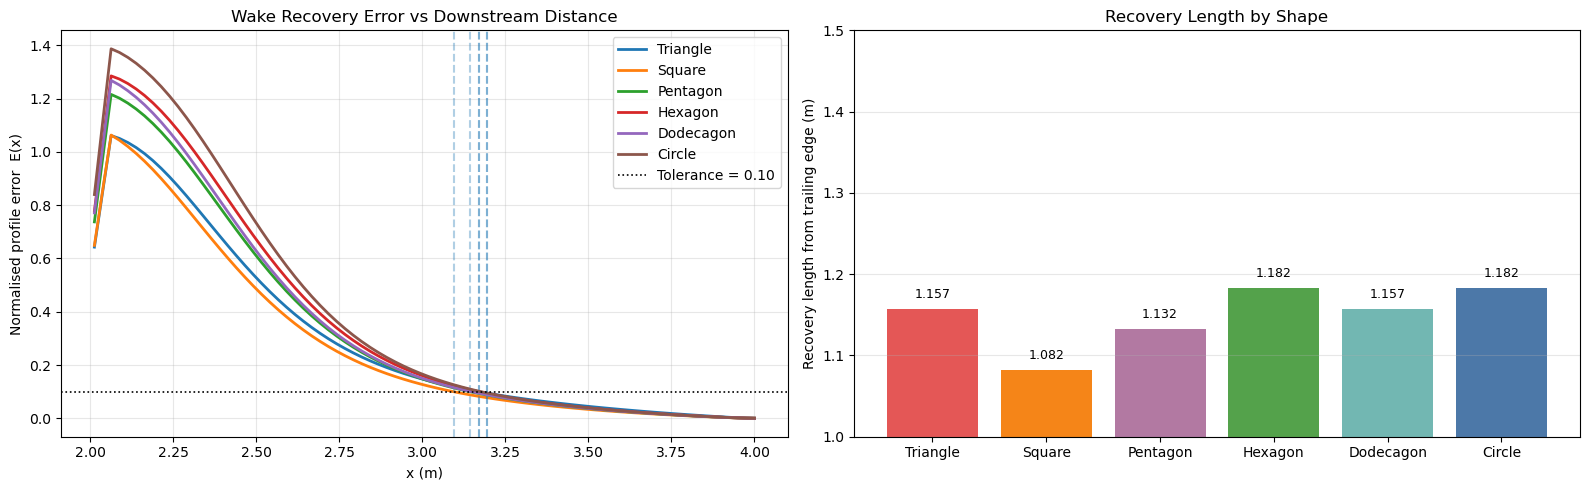

In [121]:
RECOVERY_TOL = 0.1
N_CONSECUTIVE = 6
SMOOTH_WINDOW = 5

viz_order = ["triangle", "square", "pentagon", "hexagon", "dodecagon", "circle"]


def compute_recovery_stats(shape_order, results, x_coords, recovery_tol, n_consecutive, smooth_window):
    stats = {}
    for shape_name in shape_order:
        data = results[shape_name]
        u_field = data["u"]
        v_field = data["v"]
        solid_mask = data["solid"]

        obstacle_i = np.where(np.any(solid_mask, axis=1))[0]
        i_start = min(int(obstacle_i.max()) + 1 if obstacle_i.size > 0 else 0, NX - 1)

        u_ref = u_field[-1, :]
        v_ref = v_field[-1, :]
        x_track = x_coords[i_start:].copy()
        err = np.zeros_like(x_track)

        for k, i_idx in enumerate(range(i_start, NX)):
            fluid_y = ~solid_mask[i_idx, :]
            if np.any(fluid_y):
                du = u_field[i_idx, fluid_y] - u_ref[fluid_y]
                dv = v_field[i_idx, fluid_y] - v_ref[fluid_y]
                err[k] = np.sqrt(np.mean(du**2 + dv**2)) / max(U_INLET, 1e-12)
            else:
                err[k] = np.nan

        if np.any(np.isnan(err)):
            valid = np.where(~np.isnan(err))[0]
            err = np.interp(np.arange(err.size), valid, err[valid]) if valid.size > 0 else np.zeros_like(err)

        kernel = np.ones(smooth_window) / smooth_window
        err_smooth = np.convolve(err, kernel, mode="same")

        below = err_smooth <= recovery_tol
        recovery_idx_local = None
        run = 0
        for idx_local, flag in enumerate(below):
            run = run + 1 if flag else 0
            if run >= n_consecutive:
                recovery_idx_local = idx_local - n_consecutive + 1
                break
        if recovery_idx_local is None:
            recovery_idx_local = len(x_track) - 1

        x_recovery = float(x_track[recovery_idx_local])
        x_trailing = float(x_coords[i_start]) if len(x_track) > 0 else float(x_coords[-1])

        stats[shape_name] = {
            "x": x_track,
            "error": err,
            "error_smooth": err_smooth,
            "x_trailing": x_trailing,
            "x_recovery": x_recovery,
            "recovery_length": max(0.0, x_recovery - x_trailing),
        }
    return stats


def plot_recovery_overview(recovery_stats, viz_order, recovery_tol):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    for shape_name in viz_order:
        stat = recovery_stats[shape_name]
        ax1.plot(stat["x"], stat["error_smooth"], linewidth=2, label=shape_name.capitalize())
        ax1.axvline(stat["x_recovery"], linestyle="--", alpha=0.35)

    ax1.axhline(recovery_tol, color="k", linestyle=":", linewidth=1.2,
                label=f"Tolerance = {recovery_tol:.2f}")
    ax1.set_title("Wake Recovery Error vs Downstream Distance")
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("Normalised profile error  E(x)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    lengths = [recovery_stats[s]["recovery_length"] for s in viz_order]
    colors = ["#E45756", "#F58518", "#B279A2", "#54A24B", "#72B7B2", "#4C78A8"]
    bars = ax2.bar([s.capitalize() for s in viz_order], lengths, color=colors)
    ax2.set_title("Recovery Length by Shape")
    ax2.set_ylabel("Recovery length from trailing edge (m)")
    ax2.grid(True, axis="y", alpha=0.3)
    ax2.set_ylim(1.0, 1.5)
    for bar, val in zip(bars, lengths):
        ax2.text(bar.get_x() + bar.get_width() / 2.0, val + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


recovery_stats = compute_recovery_stats(
    shape_order, results, x, RECOVERY_TOL, N_CONSECUTIVE, SMOOTH_WINDOW
)
plot_recovery_overview(recovery_stats, viz_order, RECOVERY_TOL)


## Step 5 — Pressure Drop Analysis

The pressure drop is the static pressure difference between the inlet and outlet, sampled at mid-channel height:

$$\Delta P = p(x=0,\;y=H/2) \;-\; p(x=L,\;y=H/2)$$

Higher $\Delta P$ indicates greater flow resistance. Two competing effects govern the trend with shape:

- **Frontal blockage**: smoother shapes (dodecagon, circle) present a larger projected area, increasing drag.
- **Streamlining**: angular trailing edges (triangle) shed sharper wakes, but the blunt upstream face incurs high stagnation pressure.

The net result at Re = 50 is compared across all six shapes below.


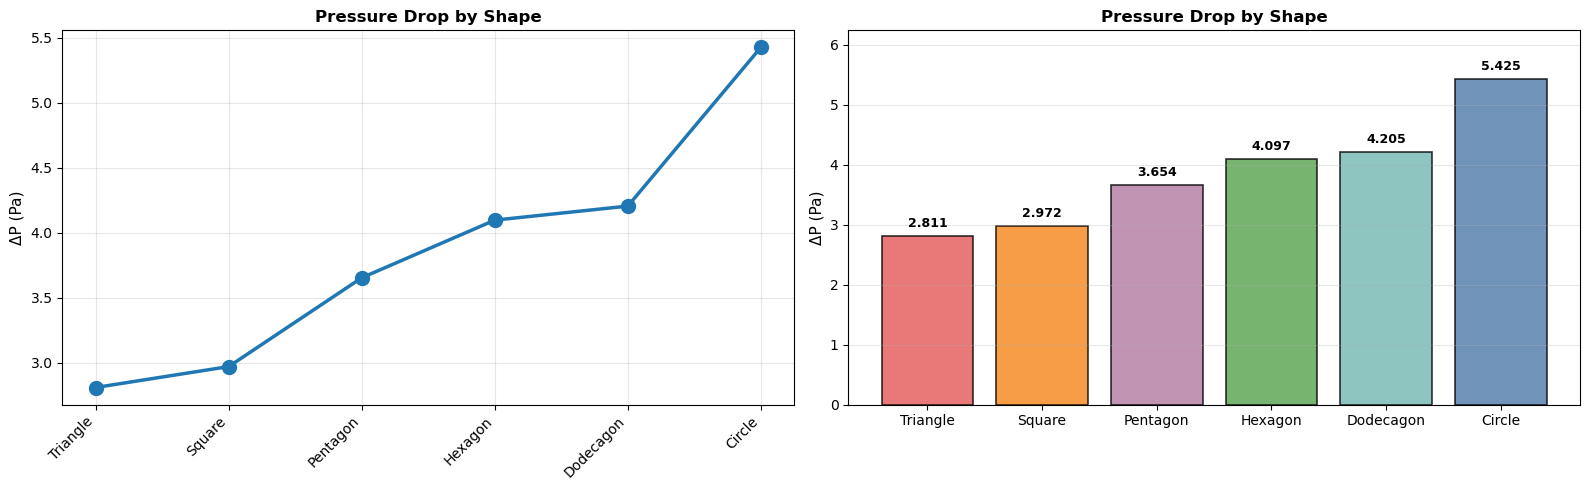

In [122]:
def compute_pressure_stats(viz_order, results):
    return {s: results[s]["pressure_drop"] for s in viz_order}


def plot_pressure_comparison(pressure_stats, viz_order):
    drops = [pressure_stats[s] for s in viz_order]
    shape_labels = [s.capitalize() for s in viz_order]
    x_pos = np.arange(len(viz_order))
    colors = ["#E45756", "#F58518", "#B279A2", "#54A24B", "#72B7B2", "#4C78A8"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(x_pos, drops, marker='o', linewidth=2.5, markersize=10, color='#1f77b4')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(shape_labels, rotation=45, ha='right')
    ax1.set_title("Pressure Drop by Shape", fontsize=12, fontweight='bold')
    ax1.set_ylabel("ΔP (Pa)", fontsize=11)
    ax1.grid(True, alpha=0.3)

    bars = ax2.bar(shape_labels, drops, color=colors, alpha=0.8,
                   edgecolor='black', linewidth=1.2)
    ax2.set_title("Pressure Drop by Shape", fontsize=12, fontweight='bold')
    ax2.set_ylabel("ΔP (Pa)", fontsize=11)
    ax2.grid(True, axis='y', alpha=0.3)
    ax2.set_ylim(0, max(drops) * 1.15)
    for bar, val in zip(bars, drops):
        ax2.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 0.1,
                 f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()


pressure_stats = compute_pressure_stats(viz_order, results)
plot_pressure_comparison(pressure_stats, viz_order)


## Summary

The figure below consolidates all results in a single layout:

- **Left column** — velocity magnitude contours with a consistent colour scale across all shapes. Orange and red dashed lines mark the trailing edge and recovery point; the annotated arrow shows $L_r$.
- **Right column** — streamlines seeded upstream of each obstacle, overlaid with the same recovery markers.
- **Bottom row** — scatter-line plots of wake recovery length (left) and pressure drop (right) ordered by number of sides, making the shape-to-shape trend immediately visible.


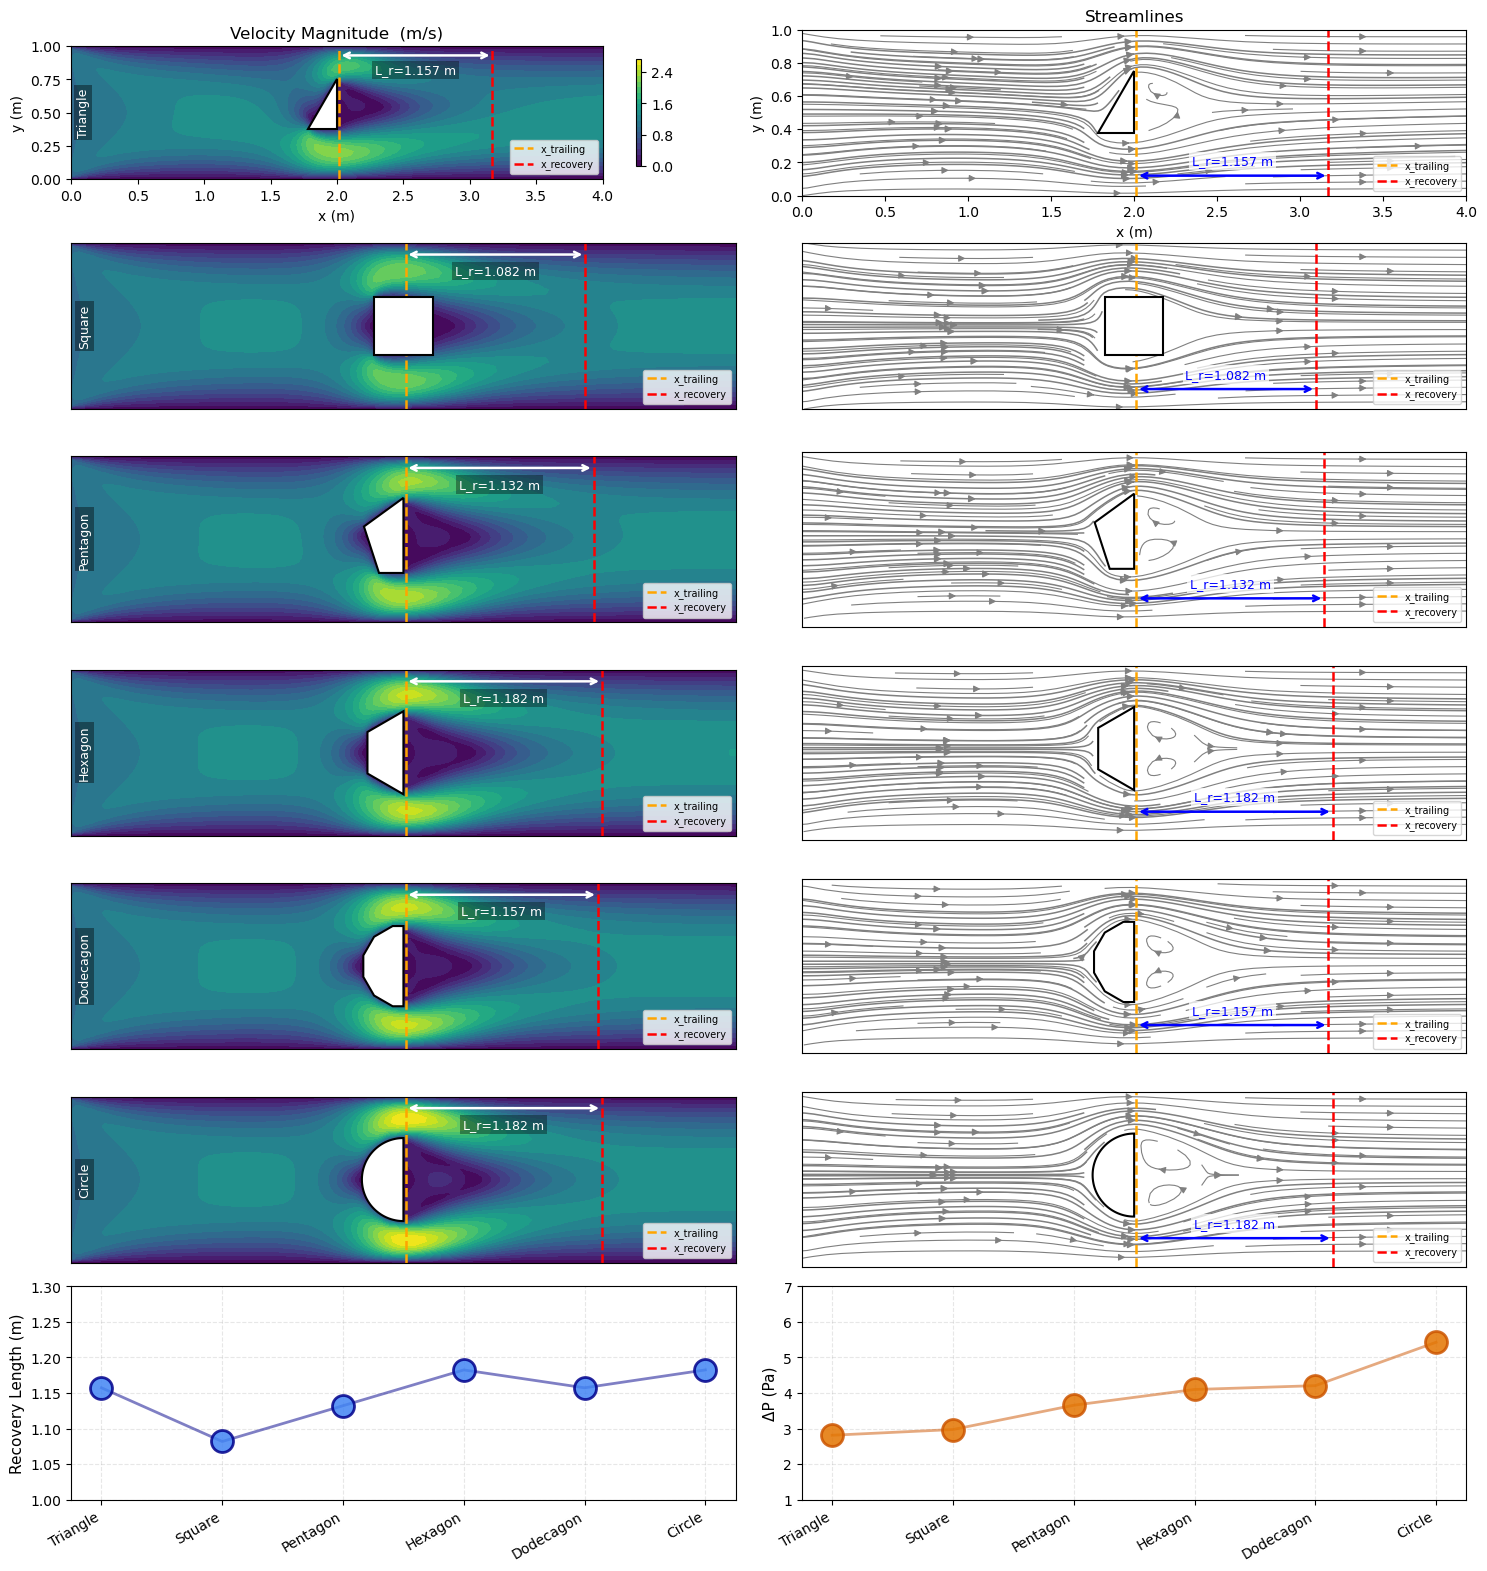

In [123]:
n_shapes = len(viz_order)
fig = plt.figure(figsize=(18, 2.4 * n_shapes + 5))
gs  = fig.add_gridspec(n_shapes + 1, 2, hspace=0.0, wspace=0.1)
axes = np.empty((n_shapes + 1, 2), dtype=object)

for i in range(n_shapes):
    axes[i, 0] = fig.add_subplot(gs[i, 0])
    axes[i, 1] = fig.add_subplot(gs[i, 1])
axes[n_shapes, 0] = fig.add_subplot(gs[n_shapes, 0])
axes[n_shapes, 1] = fig.add_subplot(gs[n_shapes, 1])

global_vmin  = min(results[s]["velocity_mag"].min() for s in viz_order)
global_vmax  = max(results[s]["velocity_mag"].max() for s in viz_order)
levels       = np.linspace(global_vmin, global_vmax, 20)
cbar_ticks   = np.arange(np.floor(global_vmin / 0.8) * 0.8,
                          np.ceil(global_vmax  / 0.8) * 0.8 + 1e-9, 0.8)

for row, shape_name in enumerate(viz_order):
    data         = results[shape_name]
    stat         = recovery_stats[shape_name]
    velocity_mag = data["velocity_mag"]
    obstacle_mask = data["solid"].T

    u_plot = data["u"].T.copy()
    v_plot = data["v"].T.copy()
    u_plot[obstacle_mask] = np.nan
    v_plot[obstacle_mask] = np.nan

    x_t = stat["x_trailing"]
    x_r = stat["x_recovery"]
    L_r = stat["recovery_length"]

    # ── Left: velocity magnitude ──────────────────────────────────────────
    ax1 = axes[row, 0]
    im  = ax1.contourf(X, Y, velocity_mag.T, levels=levels, cmap="viridis")
    ax1.set_aspect("equal")
    add_trimmed_shape_patch(ax1, shape_name)
    ax1.axvline(x_t, color="orange", linestyle="--", linewidth=1.8, label="x_trailing")
    ax1.axvline(x_r, color="red",    linestyle="--", linewidth=1.8, label="x_recovery")
    y_ann = 0.93 * HEIGHT
    ax1.annotate("", xy=(x_r, y_ann), xytext=(x_t, y_ann),
                 arrowprops=dict(arrowstyle="<->", color="white", lw=1.8))
    ax1.text((x_t + x_r) / 2, y_ann - 0.06 * HEIGHT, f"L_r={L_r:.3f} m",
             color="white", ha="center", va="top", fontsize=9,
             bbox=dict(facecolor="black", alpha=0.35, pad=2, edgecolor="none"))
    if row == 0:
        ax1.set_title("Velocity Magnitude  (m/s)")
        ax1.set_xlabel("x (m)")
        ax1.set_ylabel("y (m)")
        ax1.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)
        plt.colorbar(im, ax=ax1, shrink=0.5, format="%.1f", ticks=cbar_ticks)
    else:
        ax1.set_title("")
        ax1.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
    ax1.text(0.01, 0.5, shape_name.capitalize(), transform=ax1.transAxes,
             va="center", ha="left", fontsize=9, rotation=90, color="white",
             bbox=dict(facecolor="black", alpha=0.4, pad=2, edgecolor="none"))
    ax1.legend(loc="lower right", fontsize=7)

    # ── Right: streamlines ────────────────────────────────────────────────
    ax2 = axes[row, 1]
    ax2.streamplot(X, Y, u_plot, v_plot, density=0.8, color="gray", linewidth=0.8)

    y_seed    = np.linspace(CENTER_Y - 1.5 * CIRCUMRADIUS,
                             CENTER_Y + 1.5 * CIRCUMRADIUS, 28)
    x_seed    = np.full_like(y_seed, CENTER_X - 1.2 * CIRCUMRADIUS)
    sp        = np.column_stack([x_seed, y_seed])
    sp        = sp[(sp[:, 0] >= x.min()) & (sp[:, 0] <= x.max()) &
                   (sp[:, 1] >= y.min()) & (sp[:, 1] <= y.max())]
    ax2.streamplot(X, Y, u_plot, v_plot, start_points=sp,
                   density=2.0, color="gray", linewidth=1.1, arrowsize=1.0)

    ax2.set_aspect("equal")
    add_trimmed_shape_patch(ax2, shape_name)
    ax2.axvline(x_t, color="orange", linestyle="--", linewidth=1.8, label="x_trailing")
    ax2.axvline(x_r, color="red",    linestyle="--", linewidth=1.8, label="x_recovery")
    y_ann2 = 0.12 * HEIGHT
    ax2.annotate("", xy=(x_r, y_ann2), xytext=(x_t, y_ann2),
                 arrowprops=dict(arrowstyle="<->", color="blue", lw=1.8))
    ax2.text((x_t + x_r) / 2, y_ann2 + 0.05 * HEIGHT, f"L_r={L_r:.3f} m",
             color="blue", ha="center", va="bottom", fontsize=9,
             bbox=dict(facecolor="white", alpha=0.75, pad=2, edgecolor="none"))
    if row == 0:
        ax2.set_title("Streamlines")
        ax2.set_xlabel("x (m)")
        ax2.set_ylabel("y (m)")
        ax2.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)
    else:
        ax2.set_title("")
        ax2.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
    ax2.legend(loc="lower right", fontsize=7)

# ── Bottom row: metric scatter plots ─────────────────────────────────────────
recovery_lengths = [recovery_stats[s]["recovery_length"] for s in viz_order]
pressure_drops   = [pressure_stats[s]                    for s in viz_order]
x_positions      = np.arange(len(viz_order))
shape_labels     = [s.capitalize()                        for s in viz_order]

ax_rec  = axes[n_shapes, 0]
ax_pres = axes[n_shapes, 1]

ax_rec.scatter(x_positions, recovery_lengths, s=250, marker="o",
               color="#4285F4", edgecolors="darkblue", linewidth=2.0, zorder=5, alpha=0.85)
ax_rec.plot(x_positions, recovery_lengths, color="darkblue", linewidth=2.0, alpha=0.5, zorder=3)
ax_rec.set_xticks(x_positions)
ax_rec.set_xticklabels(shape_labels, rotation=30, ha="right", fontsize=10)
ax_rec.set_ylabel("Recovery Length (m)", fontsize=11)
ax_rec.grid(True, alpha=0.3, linestyle="--")
ax_rec.set_ylim(1.0, 1.3)

ax_pres.scatter(x_positions, pressure_drops, s=250, marker="o",
                color="#E37400", edgecolors="#CC5500", linewidth=2.0, zorder=5, alpha=0.85)
ax_pres.plot(x_positions, pressure_drops, color="#CC5500", linewidth=2.0, alpha=0.5, zorder=3)
ax_pres.set_xticks(x_positions)
ax_pres.set_xticklabels(shape_labels, rotation=30, ha="right", fontsize=10)
ax_pres.set_ylabel("ΔP (Pa)", fontsize=11)
ax_pres.grid(True, alpha=0.3, linestyle="--")
ax_pres.set_ylim(1.0, 7.0)

plt.show()